# Quality Control

In [11]:
# load packages
suppressPackageStartupMessages({
    library(Matrix)
    library(biomaRt)
    library(ggplot2)
    library(knitr)
    library(scales)
    library(viridis)
    library(cowplot)
    library(gridExtra)
})

options(repr.plot.width=15, repr.plot.height=8)

In [12]:
#core functions inc. colour palette
#source("/rds/project/bg200/rds-bg200-hphi-gottgens/users/mlnt2/PhD_MT07_Mixl1/core_functions.R")

main = '/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/'
exp_design = read.csv2(paste0(main, 'experimental_design_meta_Stat3.csv'))

# Correct batch number to be in right order!
exp_design = exp_design[order(exp_design$Barcode),]
exp_design$batch = 1:nrow(exp_design)

counts = readMM(paste0(main, "02_calledCells/raw_counts.mtx"))
genes = read.table(paste0(main, "02_calledCells/genes.tsv"), stringsAsFactors = F)
barcodes = read.table(paste0(main, "02_calledCells/barcodes.tsv"), stringsAsFactors = F)[,1]


out_dir = paste0(main, '03_quality_control/')
dir.create(out_dir, showWarnings = FALSE)

exp_design

,Pool,Barcode,Sequence,Sample.name,stage,batch,batch_name,tdTom
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>
3,SLX-21143,SITTA2,GTGGATCAAA-GCCAACCCTG,MLT_31+ Tom,E8.5,1,SLX-21143_SITTA2_HTJH3DSX2,positive
9,SLX-21143,SITTA4,CTCTAGCGAG-TATCTTCATC,MLT_3+,E8.5,2,SLX-21143_SITTA4_HTJH3DSX2,positive
4,SLX-21143,SITTB2,TCTACCATTT-CGGGAGAGTC,MLT_31- Tom,E8.5,3,SLX-21143_SITTB2_HTJH3DSX2,negative
10,SLX-21143,SITTB4,GTAGACGAAA-CTAGTGTGGT,MLT_3-,E8.5,4,SLX-21143_SITTB4_HTJH3DSX2,negative
11,SLX-21143,SITTC4,TTCTCGATGA-TGTCGGGCAC,MLT_4+,E8.5,5,SLX-21143_SITTC4_HTJH3DSX2,positive
12,SLX-21143,SITTD4,GCAGTATAGG-TTCCGTGCAC,MLT_4-,E8.5,6,SLX-21143_SITTD4_HTJH3DSX2,negative
13,SLX-21143,SITTD5,TGGTTCGGGT-GTGGCAGGAG,MLT_L+,E8.5,7,SLX-21143_SITTD5_HTJH3DSX2,positive
5,SLX-21143,SITTE3,ACCAGACAAC-AGGAACTAGG,MLT_1+,E8.5,8,SLX-21143_SITTE3_HTJH3DSX2,positive
14,SLX-21143,SITTE5,CGCGGTAGGT-CAGGATGTTG,MLT_L-,E8.5,9,SLX-21143_SITTE5_HTJH3DSX2,negative


In [13]:
dim(counts)

[1] 29453 48263

In [14]:
lib.sizes = Matrix::colSums(counts)

split_bc = strsplit(as.character(barcodes), "-", fixed = T)
bcs = sapply(split_bc, function(x) x[1])
samples = sapply(split_bc, function(x) x[2])

In [15]:
head(lib.sizes)

[1] 53197 24165 34341 41496 44249 17237

In [16]:
###==Cell Complexity Thresholding==###

#=Create function to plot change=#

plot_change = function(barcodes, logical_keep){
  
  pdf = data.frame(Sample = unique(samples),
                   Total = sapply(unique(samples), function(x) sum(samples == x)),
                   Dropped = sapply(unique(samples), function(x) sum(!logical_keep[samples == x])),
                   Retained = sapply(unique(samples), function(x) sum(logical_keep[samples == x])))
  
  p = ggplot(data = pdf) +
          geom_bar(mapping = aes(y = Total, 
                                 x = factor(Sample, levels = unique(samples))), 
                   fill = "darkgrey",
                   stat = "identity") +
          geom_bar(mapping = aes(y = Retained, 
                                 x = factor(Sample, levels = unique(samples))), 
                   fill = "coral",
                   stat = "identity") +
          geom_segment(mapping = aes(y = Total, 
                                     yend = Retained, 
                                     x = factor(Sample, levels = unique(samples)),  
                                     xend = factor(Sample, levels = unique(samples))),
                       arrow = arrow(length = unit(0.1, "inches"))) +
          theme_bw() + 
          theme(text = element_text(size=20)) +
          labs(y = "Number of cells", x= "Sample") 
  
  pdf = rbind(pdf, data.frame(Sample = "Total", 
                              Total = length(barcodes), 
                              Dropped = sum(!logical_keep), 
                              Retained = sum(logical_keep)))
    
  return(list(plot = p, df = pdf))
}

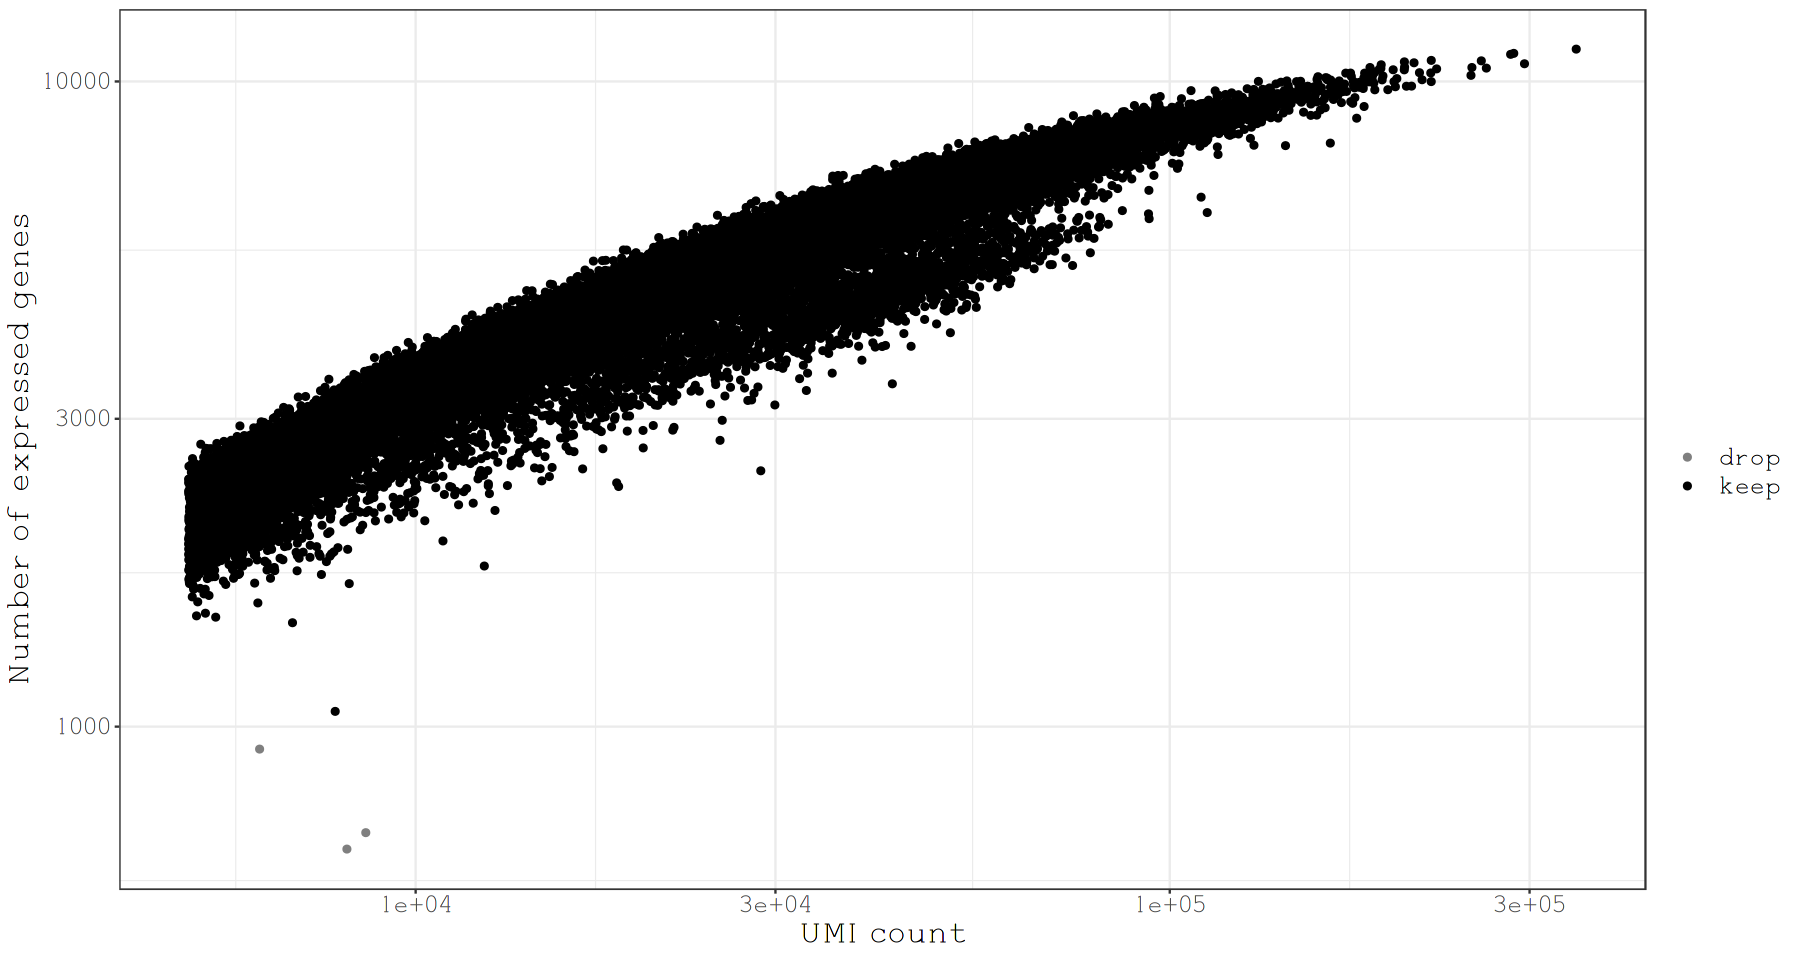

In [17]:
#=Drop cells with low gene counts (<1000)=#

lib.sizes = Matrix::colSums(counts)

ngenes = Matrix::colSums(counts > 0)


p1 = qplot(lib.sizes, ngenes, col = ifelse(ngenes < 1000, "drop", "keep")) +
  scale_x_log10() +
  scale_y_log10() +
  labs(x = "UMI count", y = "Number of expressed genes") +
  scale_color_manual(values = c("drop" = "grey50", "keep" = "black"), name = "") +
  theme_bw() + 
  theme(text = element_text(size=20)) 
p1

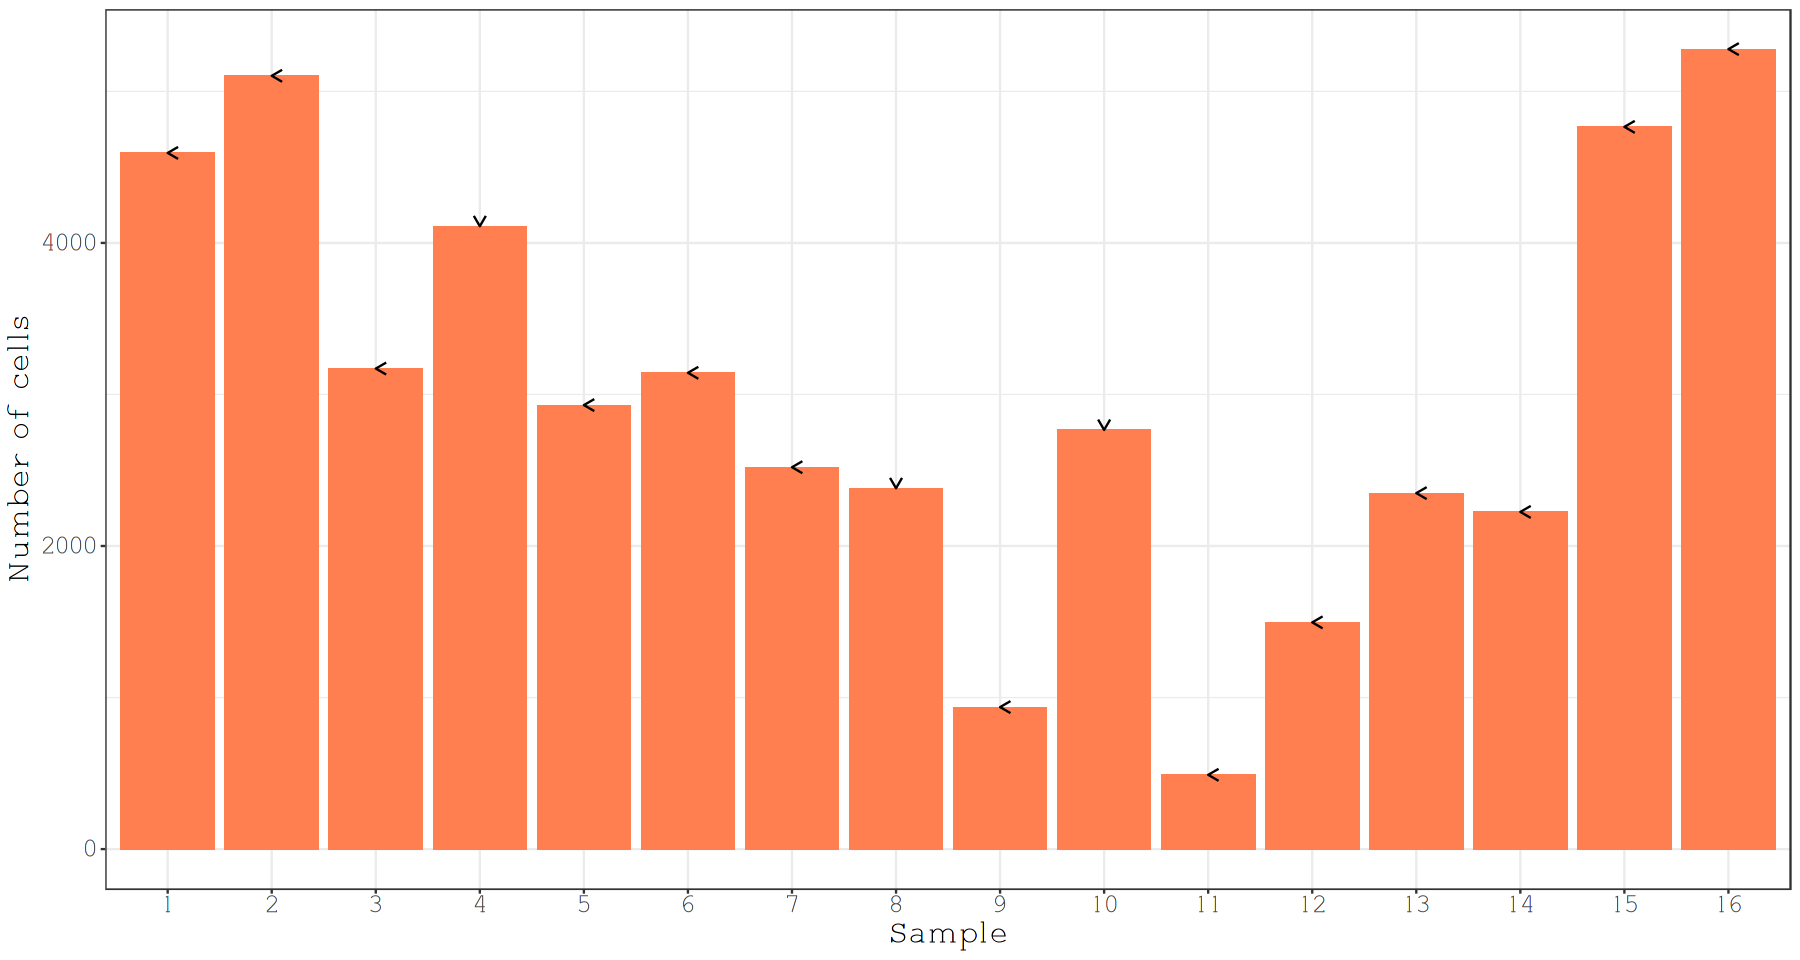

In [21]:
gene_drop = plot_change(barcodes, logical_keep = ngenes > 1000 )

print(gene_drop$plot)

In [22]:
kable(gene_drop$df, caption = "Cells dropped according to low library complexity thresholding.", row.names = FALSE)



Table: Cells dropped according to low library complexity thresholding.

|Sample | Total| Dropped| Retained|
|:------|-----:|-------:|--------:|
|1      |  4594|       0|     4594|
|2      |  5103|       0|     5103|
|3      |  3171|       0|     3171|
|4      |  4111|       1|     4110|
|5      |  2930|       0|     2930|
|6      |  3143|       0|     3143|
|7      |  2520|       0|     2520|
|8      |  2382|       1|     2381|
|9      |   937|       0|      937|
|10     |  2767|       1|     2766|
|11     |   490|       0|      490|
|12     |  1496|       0|     1496|
|13     |  2349|       0|     2349|
|14     |  2225|       0|     2225|
|15     |  4766|       0|     4766|
|16     |  5279|       0|     5279|
|Total  | 48263|       3|    48260|

In [23]:
counts = counts[, ngenes > 1000]
barcodes = barcodes[ngenes > 1000]
bcs = bcs[ngenes > 1000]
samples = samples[ngenes > 1000]
ngenes = ngenes[ngenes > 1000]

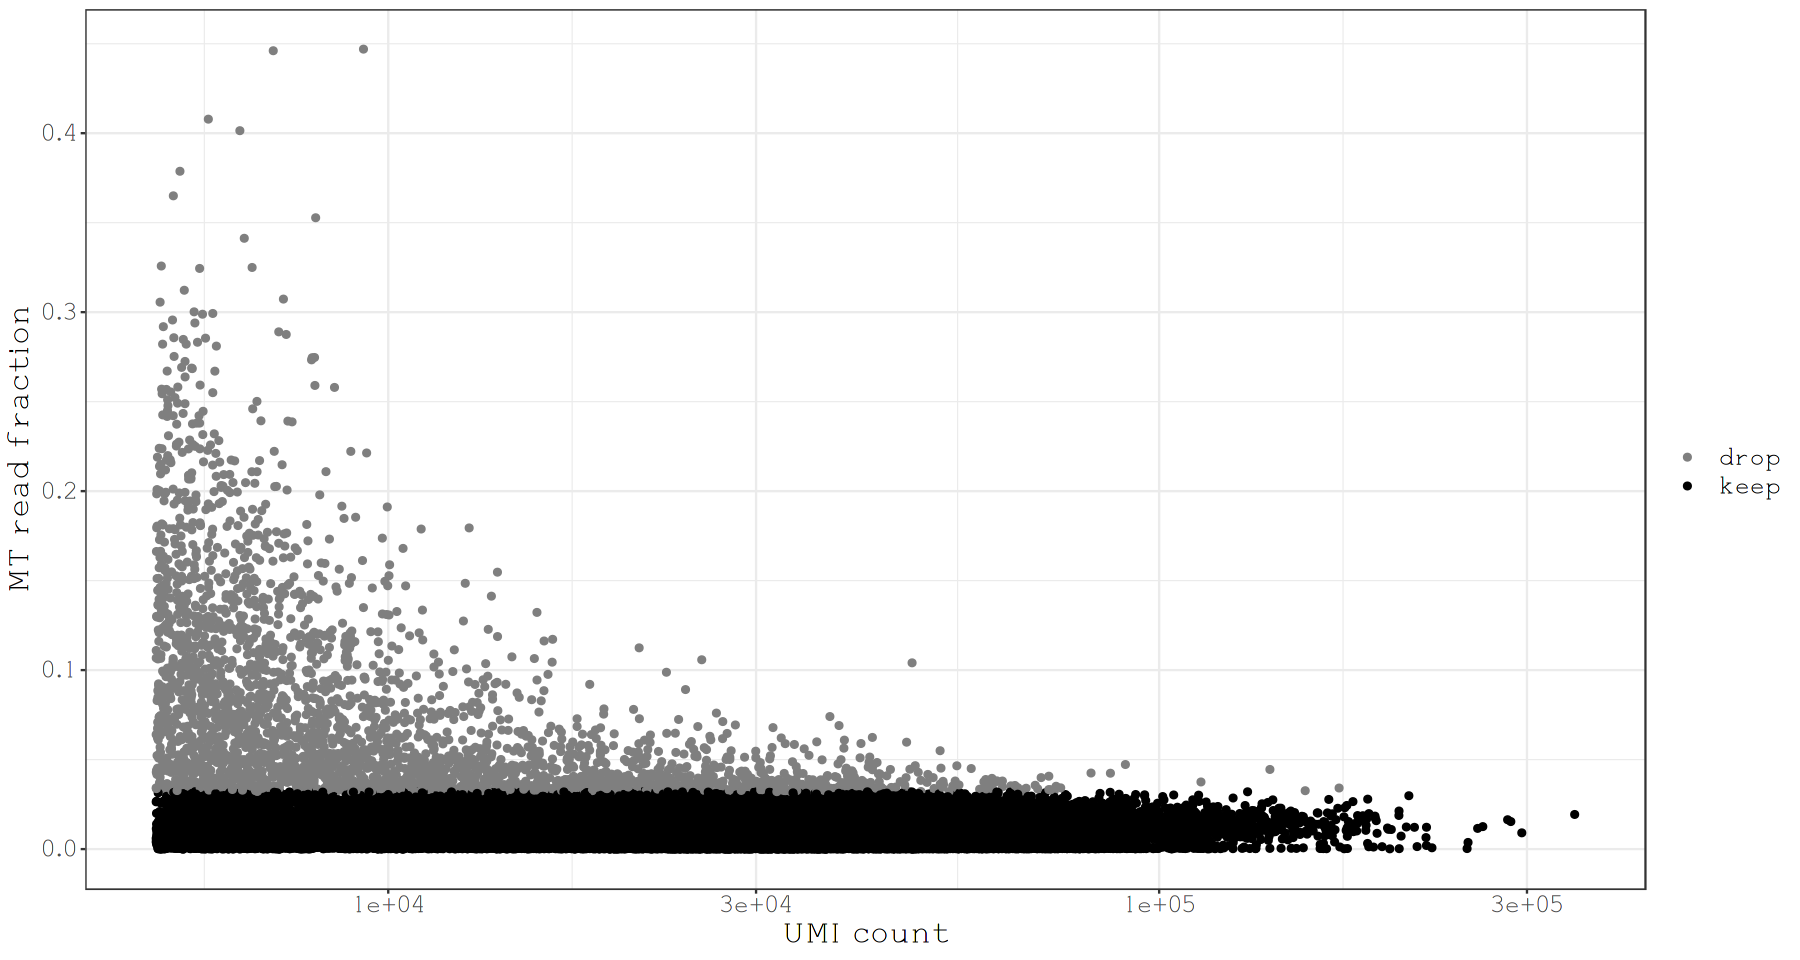

In [24]:
##==Filter cells based on high MT fraction (stressed, apoptotic cells)==##

lib.sizes = colSums(counts)

mouse_ensembl = useMart("ensembl")
mouse_ensembl = useDataset("mmusculus_gene_ensembl", mart = mouse_ensembl)

gene_map = getBM(attributes=c("ensembl_gene_id", "chromosome_name"), values = genes, mart = mouse_ensembl)
mt.counts = counts[which(genes[,1] %in% gene_map$ensembl_gene_id[gene_map$chromosome_name=="MT"]),]

mt.fraction = colSums(mt.counts)/lib.sizes

#fit median-centered, MAD-variance normal 
#crass 5%+
# mt.lim = qnorm(0.95, mean = median(mt.fraction), sd = mad(mt.fraction))
#fdr-corrected outliers
#technically this should be a pt, but the df. is astronomically high so this is essentially the same
mt.p = pnorm(mt.fraction, mean = median(mt.fraction), sd = mad(mt.fraction), lower.tail = FALSE)
mt.lim = min(mt.fraction[which(p.adjust(mt.p, method = "fdr") < 0.05)])

p2 = qplot(lib.sizes, mt.fraction, col = ifelse(mt.fraction>mt.lim, "drop", "keep")) +
  scale_x_log10() +
  labs(x = "UMI count", y = "MT read fraction") +
  scale_color_manual(values = c("drop" = "grey50", "keep" = "black"), name = "") + 
  theme_bw() + 
  theme(text = element_text(size=20)) 
p2

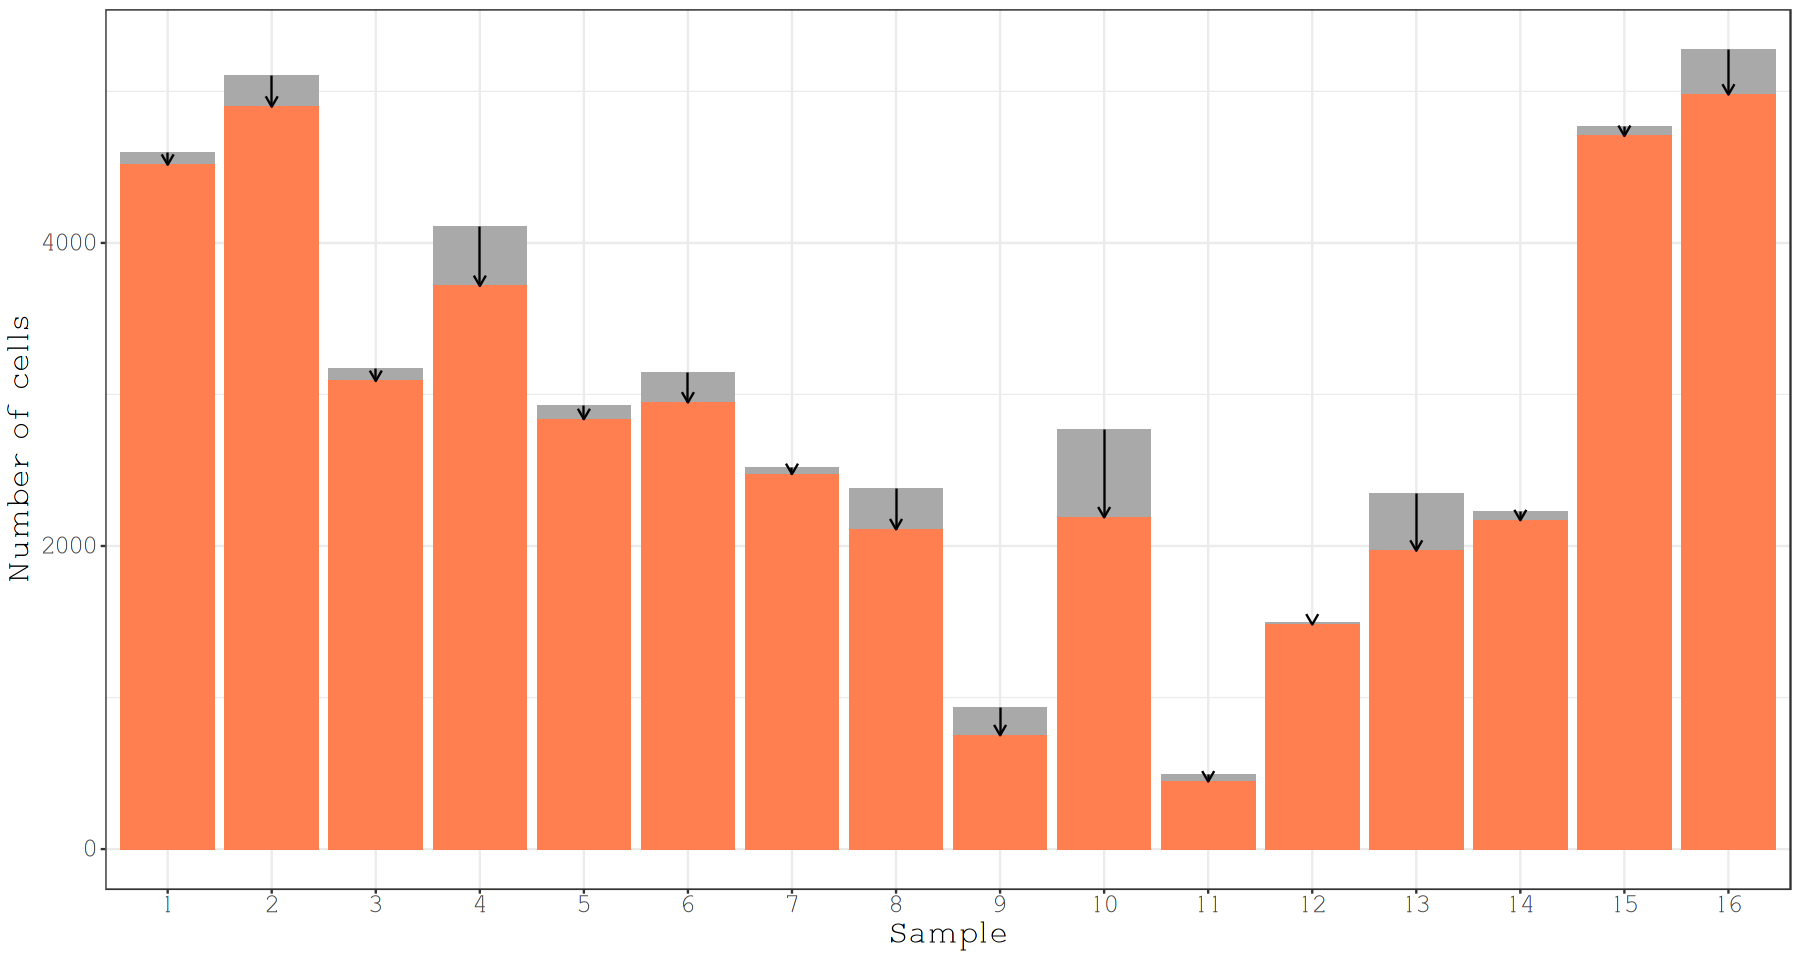

In [25]:
mt_drop = plot_change(barcodes, logical_keep = mt.fraction<mt.lim )

print(mt_drop$plot)

In [26]:
kable(mt_drop$df, caption = "Cells dropped according to mitochondrial fraction threshold", row.names = FALSE)



Table: Cells dropped according to mitochondrial fraction threshold

|Sample | Total| Dropped| Retained|
|:------|-----:|-------:|--------:|
|1      |  4594|      78|     4516|
|2      |  5103|     204|     4899|
|3      |  3171|      82|     3089|
|4      |  4110|     394|     3716|
|5      |  2930|      93|     2837|
|6      |  3143|     196|     2947|
|7      |  2520|      45|     2475|
|8      |  2381|     271|     2110|
|9      |   937|     186|      751|
|10     |  2766|     577|     2189|
|11     |   490|      44|      446|
|12     |  1496|      14|     1482|
|13     |  2349|     380|     1969|
|14     |  2225|      55|     2170|
|15     |  4766|      60|     4706|
|16     |  5279|     300|     4979|
|Total  | 48260|    2979|    45281|

In [27]:
counts = counts[, mt.fraction < mt.lim]
barcodes = barcodes[mt.fraction < mt.lim]
bcs = bcs[mt.fraction < mt.lim]
samples = samples[mt.fraction < mt.lim]
mt.fraction = mt.fraction[mt.fraction < mt.lim]

# Number of detected genes

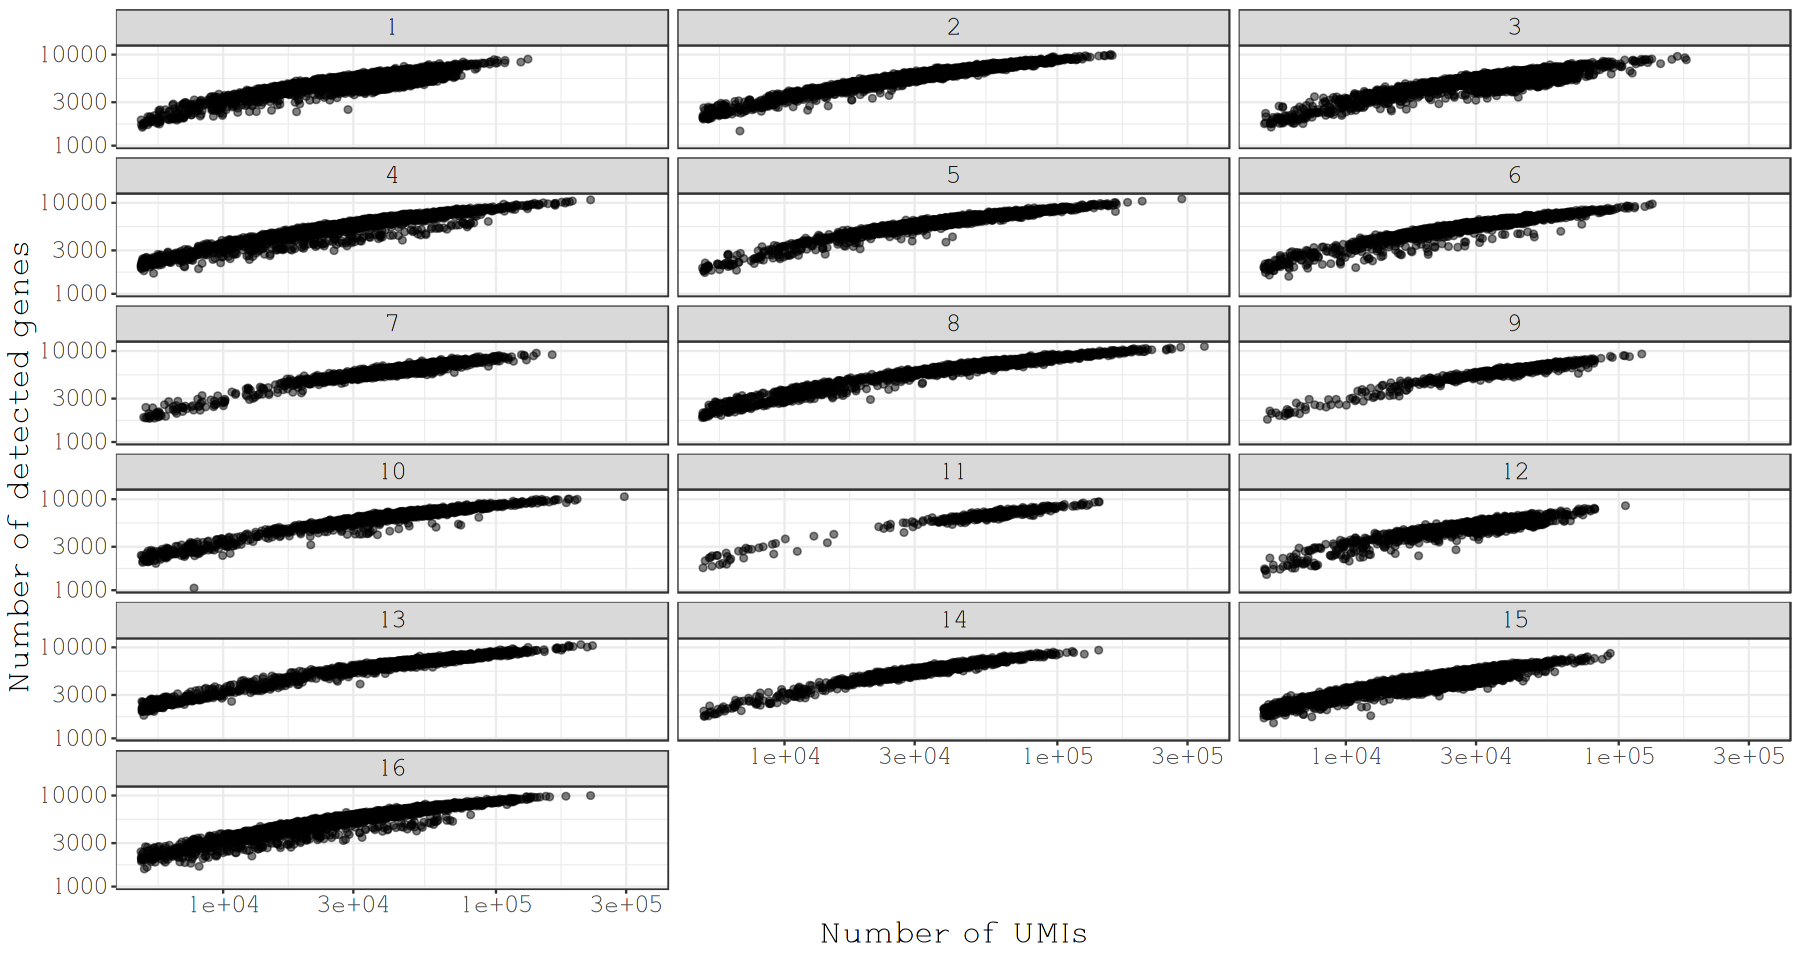

In [28]:
lib.sizes = colSums(counts)
n.genes = colSums(counts>0)

plot_df = data.frame(lib = lib.sizes, genes = n.genes, sample = samples)
plot_df = plot_df[sample(nrow(plot_df), nrow(plot_df), replace = FALSE),]

p3 = ggplot(plot_df, aes(x = lib, y = genes)) +
  geom_point(alpha = 0.5) +
 # scale_colour_Publication() +
  scale_y_log10() +
  scale_x_log10() +
  theme_bw() +
  theme(text = element_text(size=20)) +
  facet_wrap(~factor(sample, levels = unique(sample)[order(nchar(unique(as.character(sample))), unique(sample))]), ncol = 3) +
  labs(x = "Number of UMIs", y = "Number of detected genes")

suppressWarnings(plot(p3))

# Inter-sample Comparisons

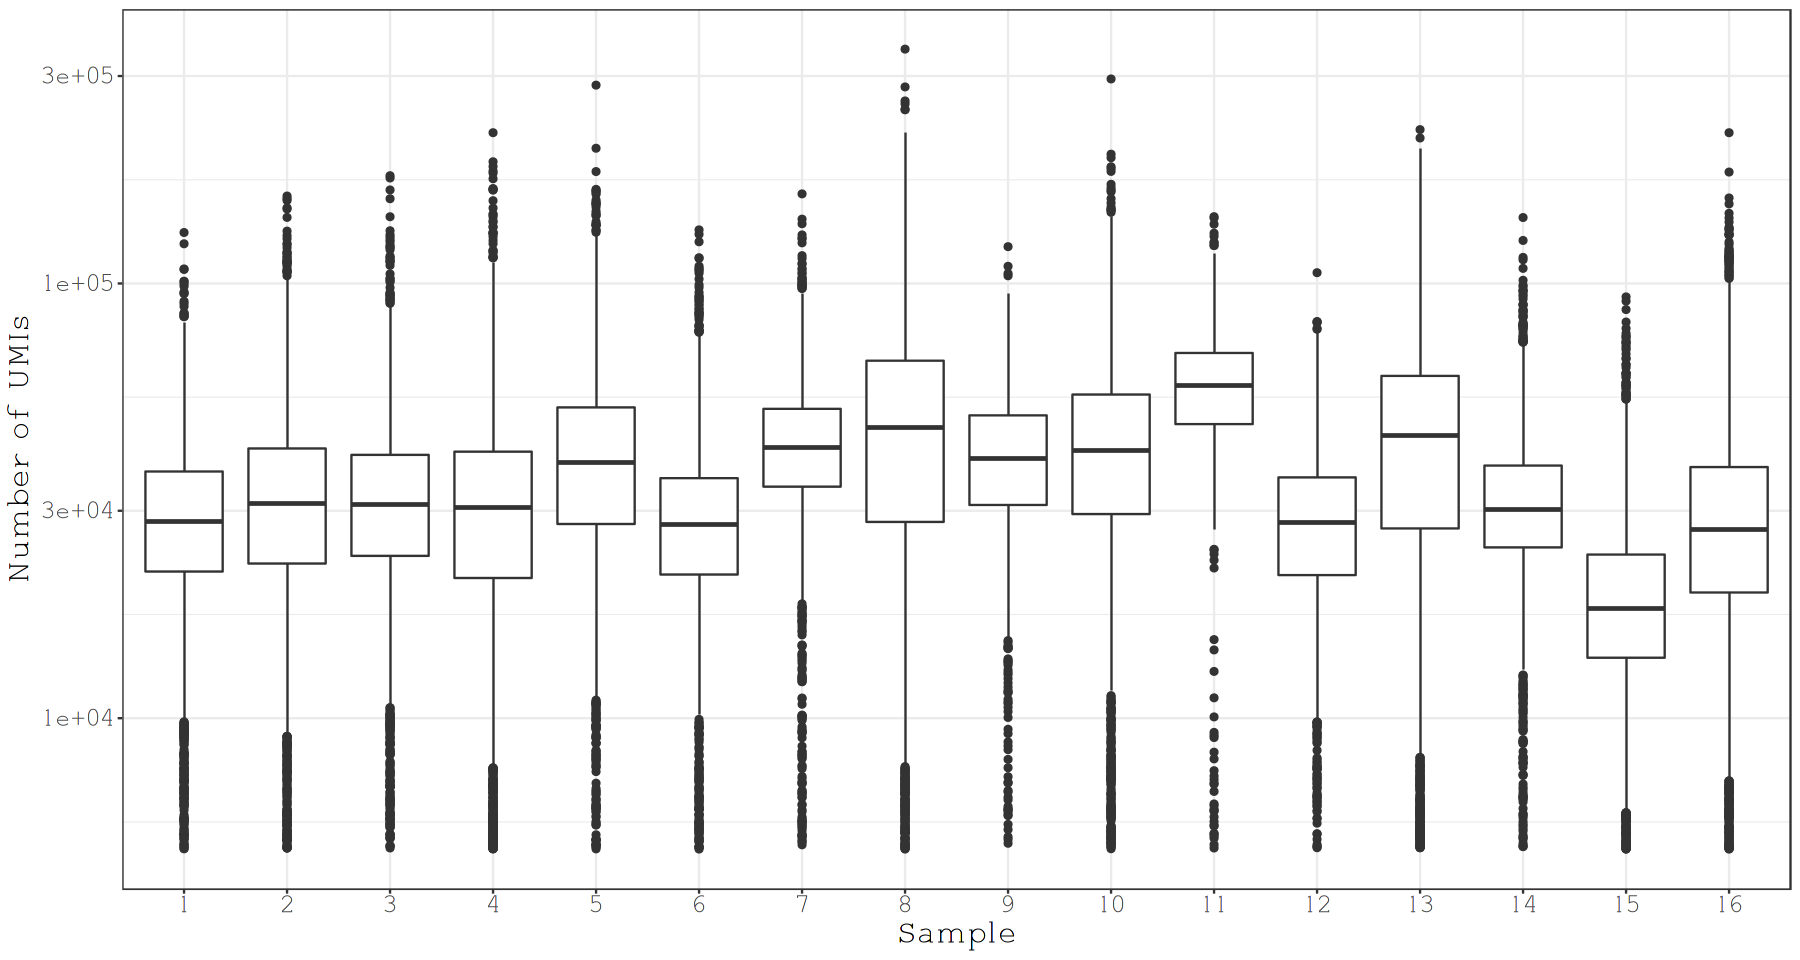

In [29]:
p4 = ggplot(data.frame(lib = lib.sizes, sample = samples), aes (x = factor(sample, levels = unique(sample)), 
                                                           y = lib.sizes)) +
  geom_boxplot() +
  theme_bw() +
  theme(text = element_text(size=20),legend.position = "none") +
  scale_y_log10() +
  labs(x = "Sample", y = "Number of UMIs")+
  scale_color_brewer(palette = "Set1", name = "Sequencing\nbatch")

suppressWarnings(plot(p4))

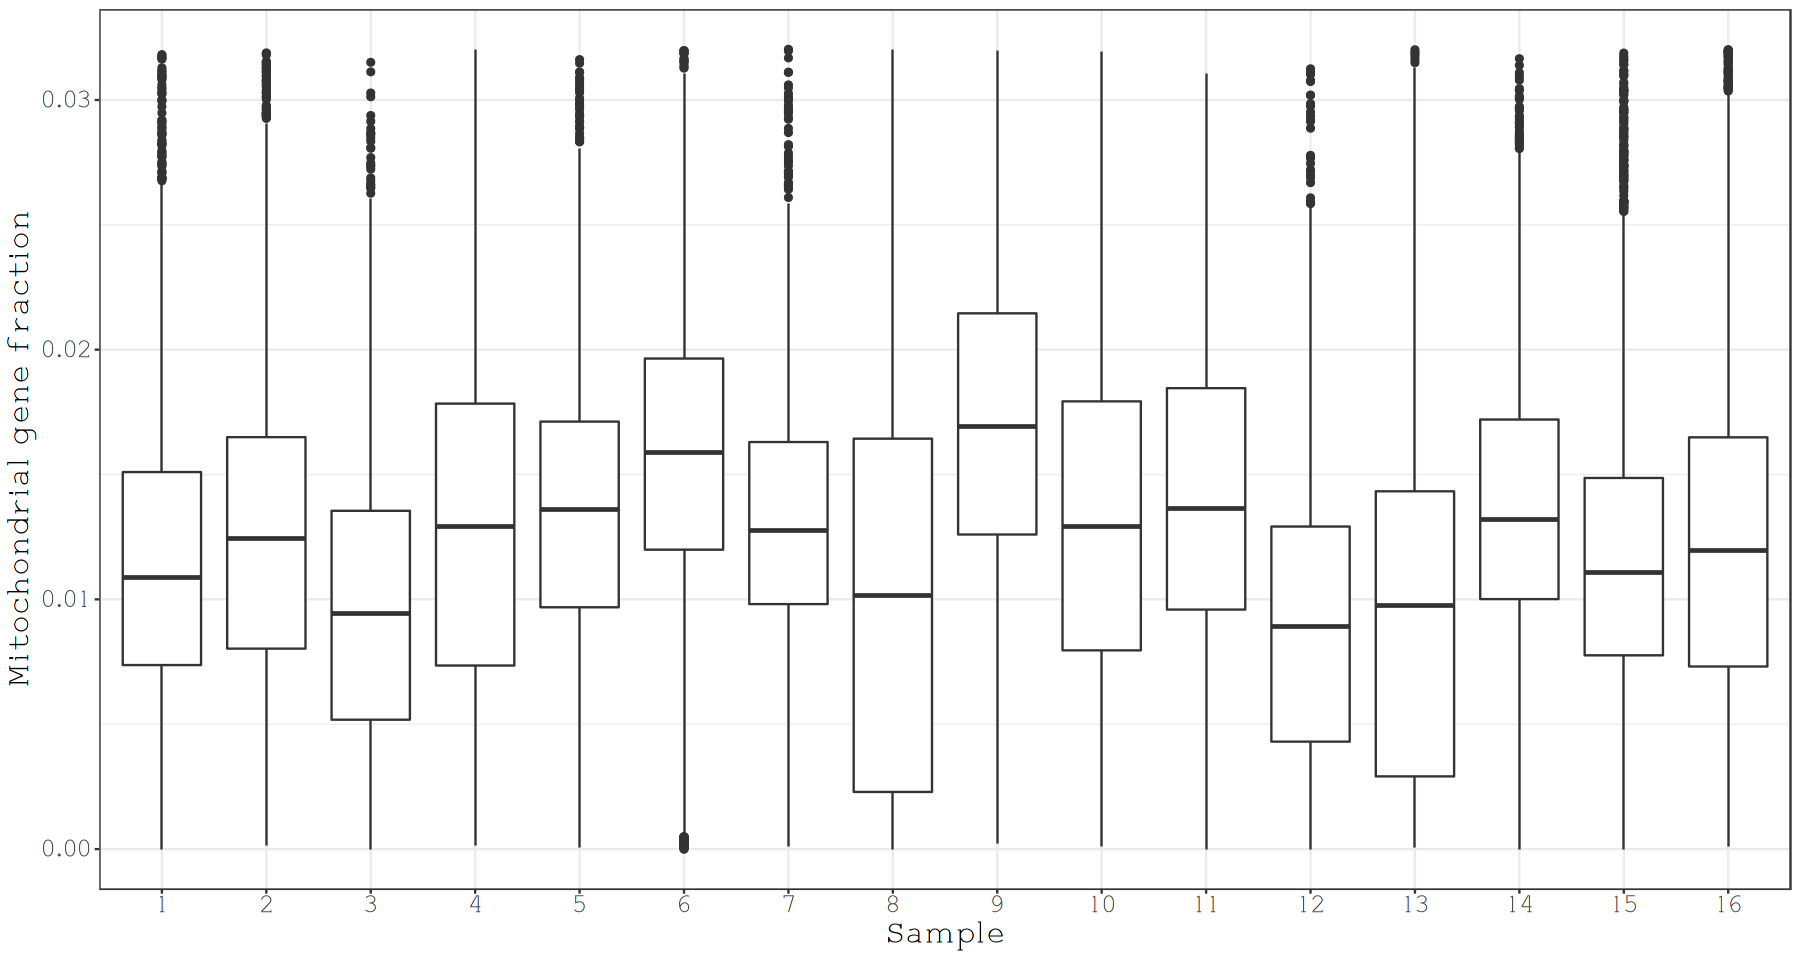

In [30]:
p5 = ggplot(data.frame(mt = mt.fraction, sample = samples), aes (x = factor(sample, levels = unique(sample)), 
                                                           y = mt)) +
  geom_boxplot() +
  theme_bw() + 
  theme(text = element_text(size=20),legend.position = "none") +
 # scale_y_log10() +
  labs(x = "Sample", y = "Mitochondrial gene fraction") +
  scale_color_brewer(palette = "Set1", name = "Sequencing\nbatch")

suppressWarnings(plot(p5))

In [31]:
meta = data.frame(cell = paste0("cell_", 1:ncol(counts)),
                  barcode = bcs,
                  stage = exp_design$stage[match(samples, exp_design$batch)],
                  batch = exp_design$batch[match(samples, exp_design$batch)],
                  Sample_name = exp_design$Sample.name[match(samples, exp_design$batch)],
                  batch_name = exp_design$batch_name[match(samples, exp_design$batch)],
                  tdTom = exp_design$tdTom[match(samples, exp_design$batch)]
                )

In [32]:
tail(meta)

,cell,barcode,stage,batch,Sample_name,batch_name,tdTom
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
45276,cell_45276,TTTGGTTCATGTAACC,E8.5,16,MLT_2-,SLX-21143_SITTH3_HTJH3DSX2,negative
45277,cell_45277,TTTGGTTGTCCGGATC,E8.5,16,MLT_2-,SLX-21143_SITTH3_HTJH3DSX2,negative
45278,cell_45278,TTTGTTGAGAGGTTTA,E8.5,16,MLT_2-,SLX-21143_SITTH3_HTJH3DSX2,negative
45279,cell_45279,TTTGTTGAGGCGCTTC,E8.5,16,MLT_2-,SLX-21143_SITTH3_HTJH3DSX2,negative
45280,cell_45280,TTTGTTGGTAAGATCA,E8.5,16,MLT_2-,SLX-21143_SITTH3_HTJH3DSX2,negative
45281,cell_45281,TTTGTTGGTCATCGGC,E8.5,16,MLT_2-,SLX-21143_SITTH3_HTJH3DSX2,negative


In [33]:
tab = as.matrix(table(meta$batch, meta$stage))

new_rownames = c("Total", rownames(tab))
tab = rbind(sapply(colnames(tab), function(x) sum(meta$stage == x)),
            tab)
rownames(tab) = new_rownames

pt = kable(tab, caption = "Number of cells retained for analysis")
pt



Table: Number of cells retained for analysis

|      |  E8.5|
|:-----|-----:|
|Total | 45281|
|1     |  4516|
|2     |  4899|
|3     |  3089|
|4     |  3716|
|5     |  2837|
|6     |  2947|
|7     |  2475|
|8     |  2110|
|9     |   751|
|10    |  2189|
|11    |   446|
|12    |  1482|
|13    |  1969|
|14    |  2170|
|15    |  4706|
|16    |  4979|

# tomato check

In [36]:
tdtom_count = counts[nrow(counts),]
tdtom_exp = data.frame('tdtom_count' = tdtom_count, 'batch' = samples)
tdtom_exp = merge(tdtom_exp, exp_design, by='batch')

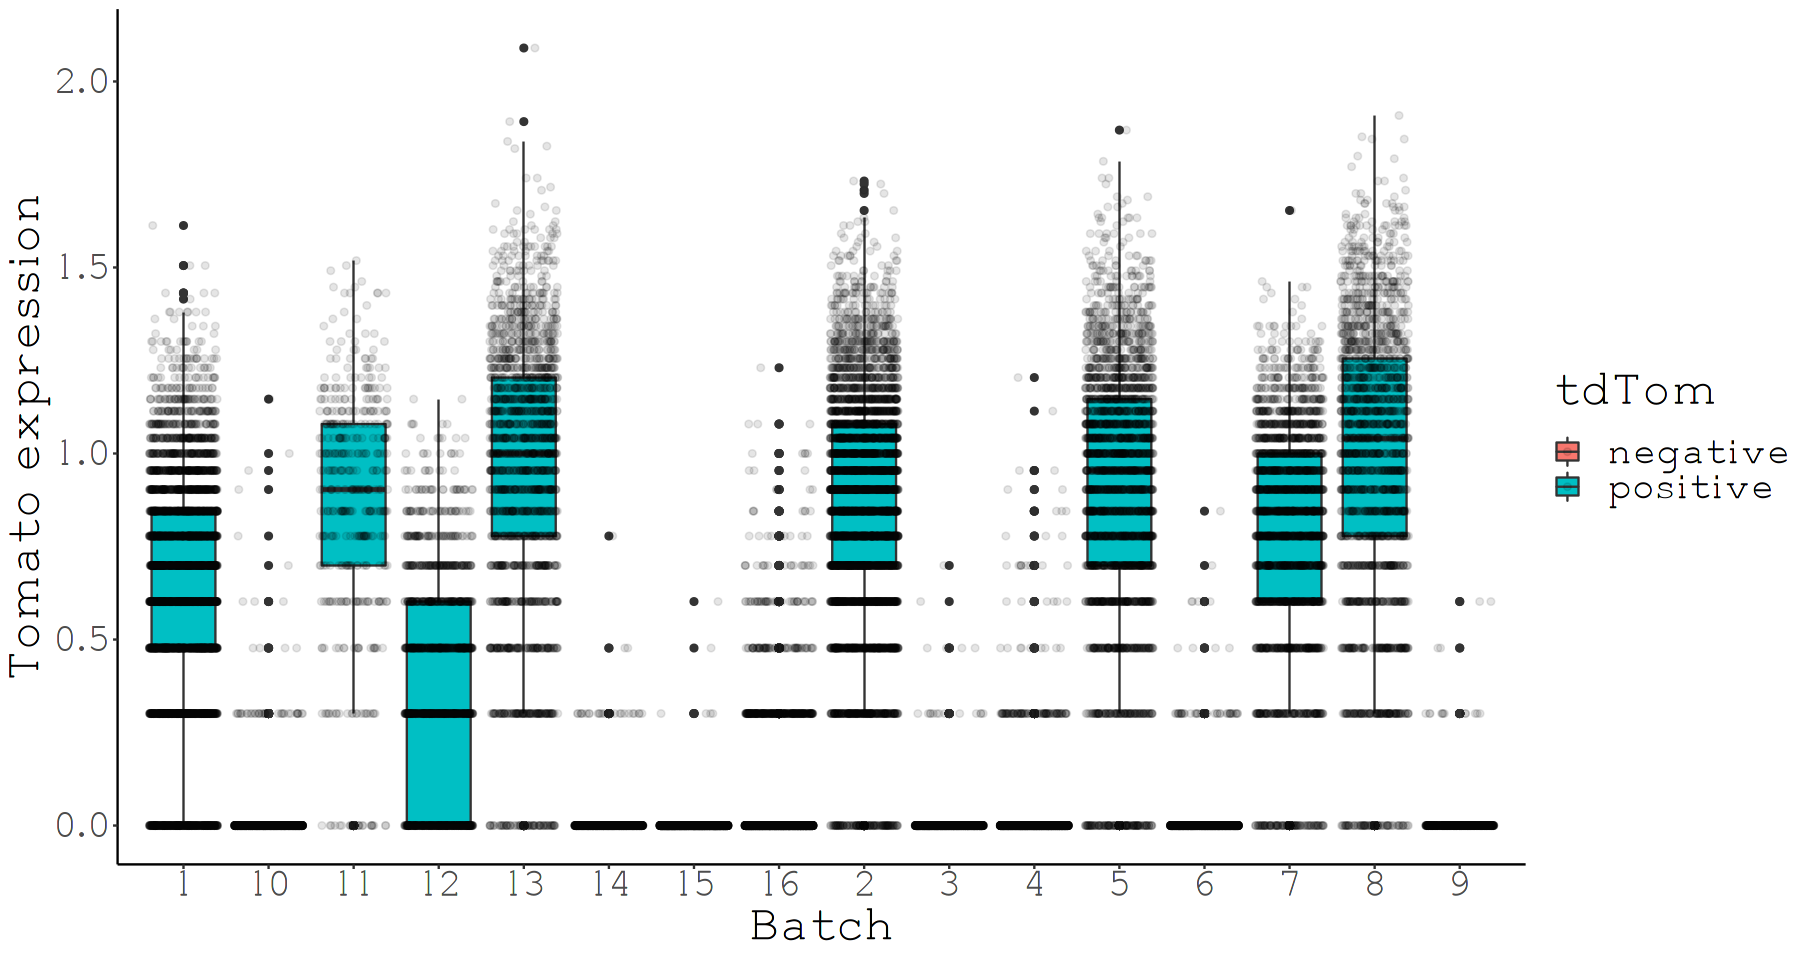

In [37]:
p6 = ggplot(tdtom_exp, aes(as.factor(batch), log10(tdtom_count+1), group=batch, fill=tdTom)) + 
    geom_boxplot() +
    geom_point(position = position_jitterdodge(jitter.width =0.8), alpha=0.1) +
    theme_classic() + 
    theme(text = element_text(size=30)) + 
    xlab('Batch') + ylab('Tomato expression')
p6
## Result is as expected, will probably look better after normalisation/scaling

### Save files & plots

In [39]:
# Save files
null_holder = writeMM(counts, file = paste0(out_dir,"matrix.mtx"))
saveRDS(as(counts, "dgCMatrix"), file = paste0(out_dir,"raw_counts.rds"))
write.table(barcodes, file = paste0(out_dir,"barcodes.tsv"), row.names = F, col.names = F, quote = F, sep = "\t")
write.table(meta, file = paste0(out_dir,"meta.tab"), row.names = F, col.names = T, quote = F, sep = "\t")

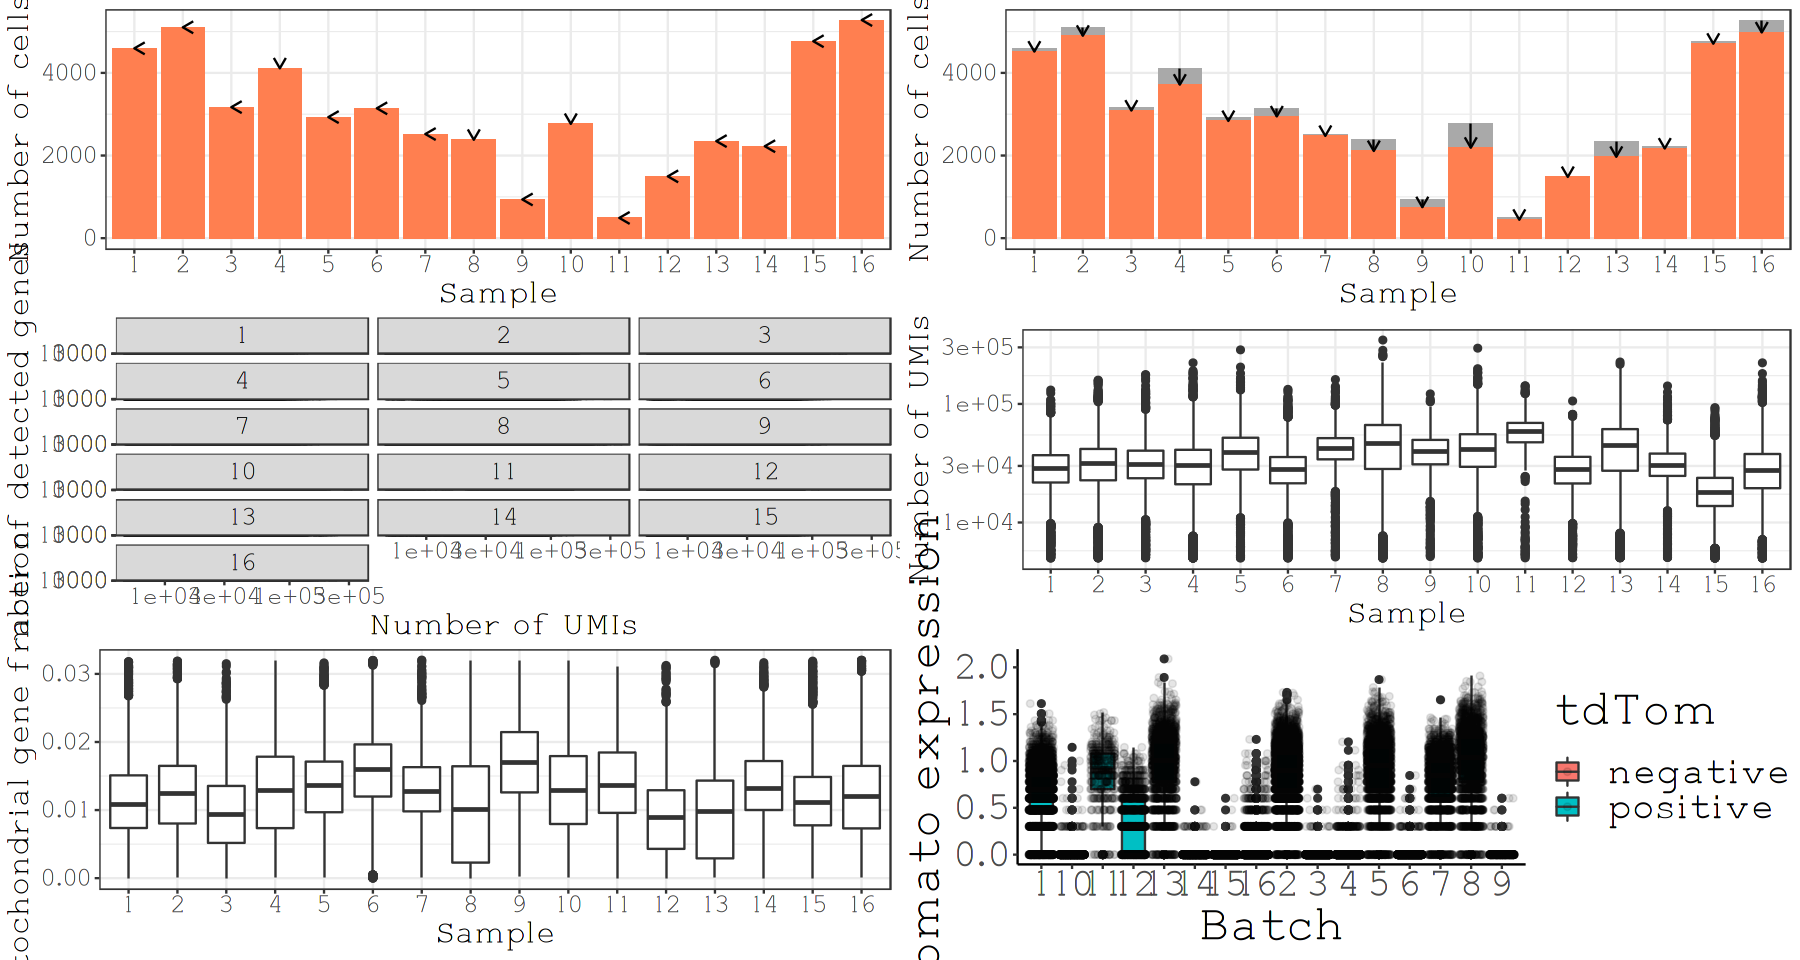

In [46]:
ggsave(filename=paste0(out_dir, 'quality_control_output.png'),
       grid.arrange(gene_drop$plot,mt_drop$plot, p3, p4,p5,p6 ,ncol=2),
       device='png',
       width=15, height=18)

In [203]:
sessionInfo()

R version 4.0.3 (2020-10-10)
Platform: x86_64-pc-linux-gnu (64-bit)
Running under: Manjaro Linux

Matrix products: default
BLAS:   /usr/local/lib64/R/lib/libRblas.so
LAPACK: /usr/local/lib64/R/lib/libRlapack.so

locale:
 [1] LC_CTYPE=en_GB.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_GB.UTF-8        LC_COLLATE=en_GB.UTF-8    
 [5] LC_MONETARY=en_GB.UTF-8    LC_MESSAGES=en_GB.UTF-8   
 [7] LC_PAPER=en_GB.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_GB.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] dplyr_1.0.4.9000  cowplot_1.1.1     viridis_0.5.1     viridisLite_0.3.0
[5] scales_1.1.1      knitr_1.30        ggplot2_3.3.3     biomaRt_2.46.0   
[9] Matrix_1.2-18    

loaded via a namespace (and not attached):
 [1] Rcpp_1.0.6           lattice_0.20-41      prettyunits_1.1.1   
 [4] getPass_0.